# Optimización por Enjambre de Partículas (PSO) en la selección de características para mejorar la Eficiencia computacional en la detección de intrusiones en entornos de Tecnologías de Operación, 2026
**Objetivo:** Implementar la Optimización por Enjambre de Partículas (PSO) para la selección de características a fin de mejorar la eficiencia computacional en la detección de intrusiones en entornos de Tecnologías de Operación, 2026.

**Variable independiente:
Optimización por Enjambre de Partículas (PSO) para la selección de características (Cuantitativo)**

Dimensiones
- Desempeño de la Función de Aptitud
Indicadores: Puntuación de fitness final, Penalización calculada por dimensionalidad
- Comportamiento de Convergencia:
Indicadores: Iteraciones hasta convergencia, Tiempo de selección
- Capacidad de almacenamiento

**Variable dependiente:
Eficiencia computacional (Cuantitativo)**

Dimensiones
-  Reducción de Dimensionalidad:
indicadores: N° de características seleccionadas, % de compresión
- Complejidad Temporal:
Indicadores: Tiempo de entrenamiento (s), Latencia de inferencia por flujo (ms)
- Huella de Recursos:
Indicadores: Uso pico de RAM (MB), so de CPU (%)


## Fase 1: Preprocesamiento - Preparación del terreno y prevención de fuga de datos.

In [25]:
# ==========================================
# CELDA 1: Importación y Configuración
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings

# Ignorar advertencias no críticas para mantener limpio el output
warnings.filterwarnings('ignore')

# Semilla de reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Librerías importadas y entorno configurado exitosamente.")

Librerías importadas y entorno configurado exitosamente.


In [26]:
# ==========================================
# CELDA 2: Carga e Inspección
# ==========================================
# NOTA: Cambia esta ruta por la ubicación real de tu CSV en Google Colab
dataset_path = '/content/Final_PowerSystem.csv'

try:
    df = pd.read_csv(dataset_path)
    print(f"Dataset cargado correctamente.")
    print(f"Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas.")

    # Mostrar las primeras filas y los tipos de datos
    display(df.head(3))

except FileNotFoundError:
    print("Error: Por favor, asegúrate de haber subido el dataset a Colab y actualizar la variable 'dataset_path'.")

Dataset cargado correctamente.
Dimensiones iniciales: 41535 filas y 129 columnas.


,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH,R1-PM3:V,R1-PA4:IH,R1-PM4:I,R1-PA5:IH,R1-PM5:I,...,control_panel_log4,relay1_log,relay2_log,relay3_log,relay4_log,snort_log1,snort_log2,snort_log3,snort_log4,marker
0,0.00000,0.407508,0.000000e+00,0.405541,0.000187,0.407702,0.000000,0.000805,0.0,0.000800,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.00037,0.403149,5.290468e-07,0.403071,0.000000,0.403380,0.000357,0.001408,0.0,0.001405,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.00000,0.405927,0.000000e+00,0.405850,0.000281,0.406158,0.000000,0.001029,0.0,0.001027,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [27]:
# ==========================================
# CELDA 3: Limpieza y Codificación
# ==========================================
# 1. Eliminación de columnas con varianza cero
# Calcular y obtener las columnas con varianza cero
columnas_varianza_cero = df.columns[df.nunique() <= 1].tolist()

# Imprimir las columnas que se van a eliminar
print(f"Columnas eliminadas por varianza cero: {columnas_varianza_cero}")

# Eliminar las columnas del DataFrame
df.drop(columns=columnas_varianza_cero, inplace=True)

# 2. Tratamiento de valores faltantes (Imputación por la mediana para no borrar filas)
nulos_iniciales = df.isnull().sum().sum()
if nulos_iniciales > 0:
    print(f"Se detectaron {nulos_iniciales} valores nulos. Aplicando imputación por mediana...")
    df.fillna(df.median(numeric_only=True), inplace=True)

# 3. Verificación de la columna Target
columna_target = 'marker'

# Como el target ya es numérico (0 y 1), solo nos aseguramos de que sea de tipo entero
df[columna_target] = df[columna_target].astype(int)

print(f"\nDimensiones tras limpieza: {df.shape}")
print("\nDistribución de la variable objetivo (1 = FDIA, 0 = NoFDIA):")
print(df[columna_target].value_counts(normalize=True) * 100) # Mostramos porcentaje

Columnas eliminadas por varianza cero: []

Dimensiones tras limpieza: (41535, 129)

Distribución de la variable objetivo (1 = FDIA, 0 = NoFDIA):
marker
0    54.686409
1    45.313591
Name: proportion, dtype: float64


In [28]:
# ==========================================
# CELDA 4: División del Dataset
# ==========================================
X = df.drop(columns=[columna_target])
y = df[columna_target]

# Dividimos 80% entrenamiento y 20% prueba, manteniendo la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f"Conjunto de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de Prueba: {X_test.shape[0]} muestras")

Conjunto de Entrenamiento: 33228 muestras
Conjunto de Prueba: 8307 muestras


In [29]:
# ==========================================
# CELDA 5: Winsorización de Outliers (IQR)
# ==========================================
# Identificamos columnas numéricas
columnas_numericas = X_train.select_dtypes(include=[np.number]).columns

# Filtramos: Solo aplicaremos Winsorización a las que tengan más de 2 valores únicos (continuas)
columnas_continuas = [col for col in columnas_numericas if X_train[col].nunique() > 2]
columnas_binarias = [col for col in columnas_numericas if X_train[col].nunique() <= 2]

print(f"Columnas continuas a winsorizar: {len(columnas_continuas)}")
print(f"Columnas binarias (excluidas de winsorización): {len(columnas_binarias)}")

def aplicar_winsorizacion_iqr(train_df, test_df, columnas):
    train_clipeado = train_df.copy()
    test_clipeado = test_df.copy()

    for col in columnas:
        # Calculamos cuartiles SOLO en el conjunto de entrenamiento
        Q1 = train_df[col].quantile(0.25)
        Q3 = train_df[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Recortamos (Clip) los valores que excedan los límites
        train_clipeado[col] = np.clip(train_df[col], limite_inferior, limite_superior)
        test_clipeado[col] = np.clip(test_df[col], limite_inferior, limite_superior)

    return train_clipeado, test_clipeado

# Aplicamos la función
X_train_win, X_test_win = aplicar_winsorizacion_iqr(X_train, X_test, columnas_continuas)
print("Winsorización completada con éxito.")
print("Ejemplo de validación (Máximos recortados en una columna aleatoria de X_train):")
col_ejemplo = columnas_continuas[0]
print(f"Max original ({col_ejemplo}): {X_train[col_ejemplo].max()} -> Max Winsorizado: {X_train_win[col_ejemplo].max()}")

Columnas continuas a winsorizar: 123
Columnas binarias (excluidas de winsorización): 5
Winsorización completada con éxito.
Ejemplo de validación (Máximos recortados en una columna aleatoria de X_train):
Max original (R1-PA1:VH): 0.0005540012474143 -> Max Winsorizado: 0.0005454703507086875


In [30]:
# ==========================================
# CELDA 6: Normalización Min-Max [0,1]
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))

# Ajustamos (fit) solo con Train, transformamos (transform) Train y Test
X_train_norm = pd.DataFrame(scaler.fit_transform(X_train_win), columns=columnas_numericas, index=X_train_win.index)
X_test_norm = pd.DataFrame(scaler.transform(X_test_win), columns=columnas_numericas, index=X_test_win.index)

print("Normalización Min-Max completada.")

Normalización Min-Max completada.


In [31]:
# ==========================================
# CELDA 7: Validación y Comprobación Final
# ==========================================
# Comprobar que no hay NaNs introducidos
assert X_train_norm.isnull().sum().sum() == 0, "Error: Hay valores nulos en X_train."
assert X_test_norm.isnull().sum().sum() == 0, "Error: Hay valores nulos en X_test."

# Comprobar los rangos [0,1] en el set de entrenamiento
stats = X_train_norm.describe()
print("Resumen estadístico de las primeras 5 variables (Train):")
display(stats.iloc[:, :5].loc[['min', 'max', 'mean']])

print("\n--- FASE DE AISLAMIENTO COMPLETADA ---")
print("El pipeline está listo para la Fase 2 (Grupo de Control) y la Fase 3 (Optimización BPSO).")

Resumen estadístico de las primeras 5 variables (Train):


,R1-PA1:VH,R1-PM1:V,R1-PA2:VH,R1-PM2:V,R1-PA3:VH
min,0.000000,0.00000,0.00000,0.000000,0.000000
max,1.000000,1.00000,1.00000,1.000000,1.000000
mean,0.214493,0.50857,0.26825,0.514311,0.248478



--- FASE DE AISLAMIENTO COMPLETADA ---
El pipeline está listo para la Fase 2 (Grupo de Control) y la Fase 3 (Optimización BPSO).


## Fase 2: Línea Base (Grupo de Control)

In [32]:
# ==========================================
# CELDA 8: Balanceo de Clases con SMOTE
# ==========================================
from imblearn.over_sampling import SMOTE

print(f"Distribución antes de SMOTE:\n{y_train.value_counts()}\n")

# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=RANDOM_SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_norm, y_train)

print(f"Distribución después de SMOTE:\n{y_train_res.value_counts()}")
print(f"Nuevas dimensiones de entrenamiento: {X_train_res.shape}")

Distribución antes de SMOTE:
marker
0    18171
1    15057
Name: count, dtype: int64

Distribución después de SMOTE:
marker
1    18171
0    18171
Name: count, dtype: int64
Nuevas dimensiones de entrenamiento: (36342, 128)


In [33]:
# ==========================================
# CELDA 9: Herramientas de Perfilamiento
# ==========================================
import time
import tracemalloc
import psutil
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def obtener_uso_memoria_cpu():
    """Captura el uso actual de RAM (MB) del proceso y CPU (%)"""
    proceso = psutil.Process(os.getpid())
    ram_mb = proceso.memory_info().rss / (1024 * 1024)
    cpu_pct = proceso.cpu_percent(interval=None)
    return ram_mb, cpu_pct

print("Librerías de perfilamiento y métricas cargadas.")

Librerías de perfilamiento y métricas cargadas.


In [34]:
# ==========================================
# CELDA 10: Entrenamiento del Baseline
# ==========================================
# Inicializamos el modelo con la semilla global
rf_base = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)

print("Iniciando entrenamiento del modelo base (100% características)...")

# Medición del tiempo de entrenamiento
t_inicio_train = time.perf_counter()
rf_base.fit(X_train_res, y_train_res)
t_fin_train = time.perf_counter()

tiempo_entrenamiento_base = t_fin_train - t_inicio_train

print(f"Entrenamiento completado en: {tiempo_entrenamiento_base:.4f} segundos.")

Iniciando entrenamiento del modelo base (100% características)...
Entrenamiento completado en: 25.2270 segundos.


In [35]:
# ==========================================
# CELDA 11: Inferencia y Métricas de Eficiencia
# ==========================================
# Preparar perfilamiento
tracemalloc.start()
psutil.cpu_percent(interval=None) # Llamada inicial de calibración

t_inicio_inf = time.perf_counter()

# Ejecución de la inferencia
y_pred_base = rf_base.predict(X_test_norm)

# Captura de tiempo y recursos
t_fin_inf = time.perf_counter()
ram_actual, ram_pico = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Procesamiento de métricas operacionales
ram_pico_mb = ram_pico / (1024 * 1024)
cpu_uso_inferencia = psutil.Process(os.getpid()).cpu_percent(interval=None)
tiempo_total_inferencia = t_fin_inf - t_inicio_inf

# Cálculo de latencia por flujo en milisegundos (ms)
latencia_flujo_base_ms = (tiempo_total_inferencia / len(X_test_norm)) * 1000

# Procesamiento de métricas de detección
acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

# Guardamos el baseline en un diccionario para la Tabla 1 y 2 del paper
resultados_base = {
    "Modelo": "RF Control (100% Dim)",
    "Características": X_train_res.shape[1],
    "CR (%)": 0.0, # 0% de compresión en el control
    "Train Time (s)": tiempo_entrenamiento_base,
    "Inference Latency (ms)": latencia_flujo_base_ms,
    "Peak RAM (MB)": ram_pico_mb,
    "Accuracy": acc_base,
    "Precision": prec_base,
    "Recall": rec_base,
    "F1-Score": f1_base
}

print("=== MÉTRICAS DEL GRUPO DE CONTROL (BASELINE) ===")
for k, v in resultados_base.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

=== MÉTRICAS DEL GRUPO DE CONTROL (BASELINE) ===
Modelo: RF Control (100% Dim)
Características: 128
CR (%): 0.0000
Train Time (s): 25.2270
Inference Latency (ms): 0.0269
Peak RAM (MB): 4.6232
Accuracy: 0.9297
Precision: 0.9309
Recall: 0.9126
F1-Score: 0.9217


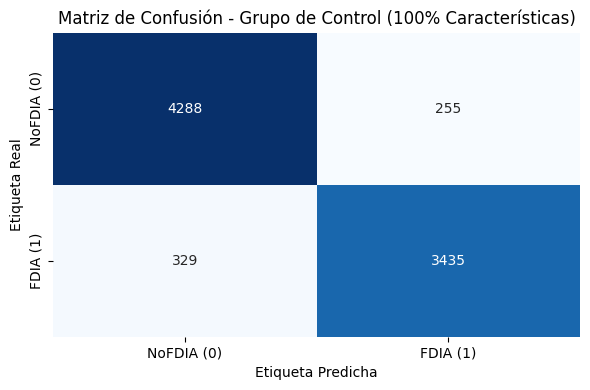

In [36]:
# ==========================================
# CELDA 12: Matriz de Confusión Base
# ==========================================
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['NoFDIA (0)', 'FDIA (1)'],
            yticklabels=['NoFDIA (0)', 'FDIA (1)'])
plt.title('Matriz de Confusión - Grupo de Control (100% Características)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

## Fase 3: Optimización Heurística (Variable Independiente)

In [37]:
# ==========================================
# CELDA 13: Función de Aptitud (Fitness) BPSO
# ==========================================
from sklearn.metrics import accuracy_score

# Hiperparámetros de la Ecuación de Fitness
ALPHA = 0.90  # 90% de peso a la capacidad de detección (minimizar error)
BETA = 0.10   # 10% de peso a la eficiencia (minimizar características)

def f_per_particle(m, alpha, beta, X_fit_train, X_fit_val, y_fit_train, y_fit_val):
    """
    Evalúa una sola partícula.
    m: vector binario [0, 1, 0...]
    """
    # Si la partícula descarta todas las características, recibe el costo máximo (1.0)
    if np.count_nonzero(m) == 0:
        return 1.0

    # Extraer subconjunto de características (máscara booleana)
    X_subset_train = X_fit_train.iloc[:, m==1]
    X_subset_val = X_fit_val.iloc[:, m==1]

    # Random Forest "ligero" para evaluación rápida durante el enjambre
    rf_eval = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=RANDOM_SEED)
    rf_eval.fit(X_subset_train, y_fit_train)
    y_pred = rf_eval.predict(X_subset_val)

    # 1. Tasa de Error
    error_rate = 1.0 - accuracy_score(y_fit_val, y_pred)

    # 2. Penalización Dimensional (||m||_1 / |F_total|)
    penalty = np.count_nonzero(m) / X_fit_train.shape[1]

    # Ecuación de Costo (A minimizar)
    cost = (alpha * error_rate) + (beta * penalty)
    return cost

def fitness_function(particles, X, y):
    """
    Itera sobre todo el enjambre devolviendo el costo de cada partícula.
    """
    n_particles = particles.shape[0]
    costs = np.zeros(n_particles)

    # División interna estricta para evitar sobreajuste en el Wrapper
    X_f_train, X_f_val, y_f_train, y_f_val = train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
    )

    for i in range(n_particles):
        costs[i] = f_per_particle(particles[i], ALPHA, BETA, X_f_train, X_f_val, y_f_train, y_f_val)

    return costs

print("Función de aptitud (Fitness) definida correctamente.")

Función de aptitud (Fitness) definida correctamente.


In [38]:
!pip install pyswarms

In [39]:
# ==========================================
# CELDA 14: Ejecución de BPSO (Variable Independiente)
# ==========================================
import pyswarms as ps
import time

# Configuración del Enjambre BPSO
# c1: cognitivo, c2: social, w: inercia, k: vecinos (debe ser <= n_particles), p: norma de distancia
options = {'c1': 1.5, 'c2': 1.5, 'w': 0.5, 'k': 20, 'p': 2}
dimensiones_totales = X_train_res.shape[1]

# Instanciar el optimizador binario
optimizer = ps.discrete.binary.BinaryPSO(
    n_particles=20,
    dimensions=dimensiones_totales,
    options=options
)

print(f"Iniciando optimización BPSO en espacio de {dimensiones_totales} dimensiones...")
t_inicio_pso = time.perf_counter()

# Ejecución de la búsqueda heurística
costo_final, mascara_binaria = optimizer.optimize(
    fitness_function,
    iters=30,
    X=X_train_res,
    y=y_train_res
)

t_fin_pso = time.perf_counter()
tiempo_seleccion_pso = t_fin_pso - t_inicio_pso

print("\nOptimización heurística completada.")

2026-05-14 00:27:26,848 - pyswarms.discrete.binary - INFO - Optimize for 30 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.5, 'k': 20, 'p': 2}


Iniciando optimización BPSO en espacio de 128 dimensiones...


pyswarms.discrete.binary: 100%|██████████|30/30, best_cost=0.201
2026-05-14 01:11:28,587 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.20115526981015272, best pos: [1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0
 0 1 1 0 1 0 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 0 1 1 1 0 1 1 0 0
 1 1 0 1 0 0 0 0 1 0 1 1 0 1 0 0 1]



Optimización heurística completada.


=== MÉTRICAS DE LA VARIABLE INDEPENDIENTE (BPSO) ===
Dimensión 1 - Puntuación de fitness final (costo): 0.2012
Dimensión 1 - Penalización por dimensionalidad: 0.4453 (Retuvo 57 de 128)
Dimensión 2 - Iteraciones hasta convergencia: 30 (Ver gráfica para estabilización)
Dimensión 2 - Tiempo de selección: 2641.76 segundos


<Figure size 800x500 with 0 Axes>

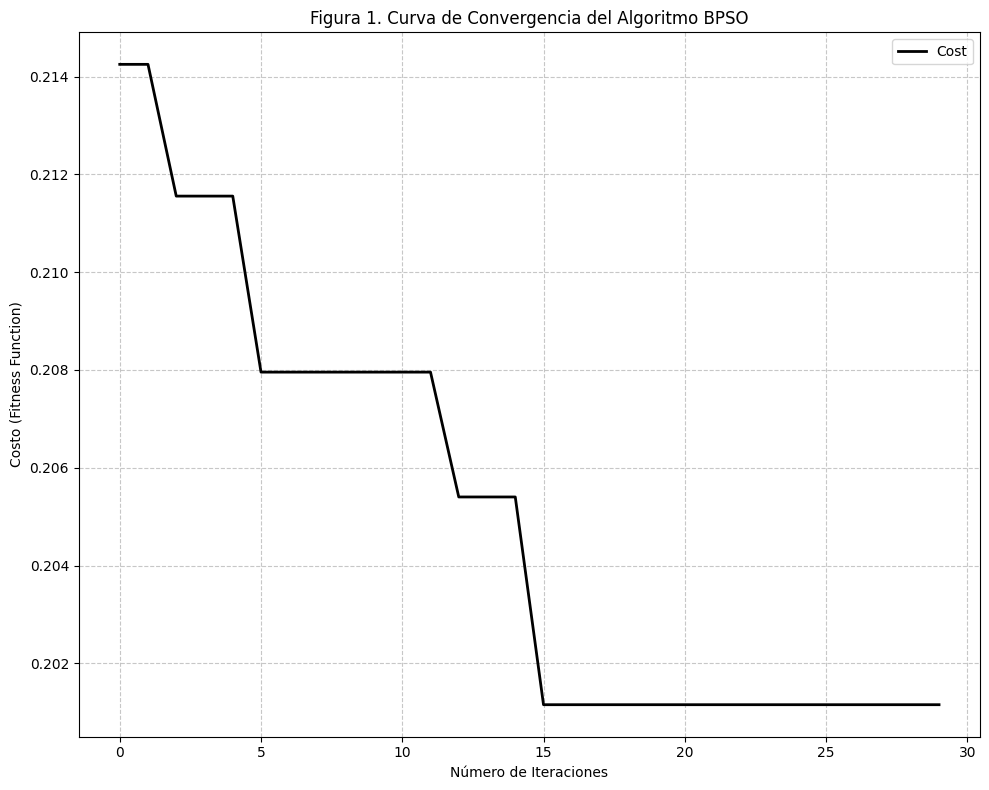


Datasets optimizados creados exitosamente. Nueva dimensión: 57 características.


In [40]:
# ==========================================
# CELDA 15: Métricas VI y Gráfica de Convergencia
# ==========================================
from pyswarms.utils.plotters import plot_cost_history

# Procesamiento de la máscara matemática (||m||_1)
mascara_optima = mascara_binaria == 1
caracteristicas_retenidas = np.count_nonzero(mascara_optima)
penalizacion_dim = caracteristicas_retenidas / dimensiones_totales

print("=== MÉTRICAS DE LA VARIABLE INDEPENDIENTE (BPSO) ===")
print(f"Dimensión 1 - Puntuación de fitness final (costo): {costo_final:.4f}")
print(f"Dimensión 1 - Penalización por dimensionalidad: {penalizacion_dim:.4f} (Retuvo {caracteristicas_retenidas} de {dimensiones_totales})")
print(f"Dimensión 2 - Iteraciones hasta convergencia: 30 (Ver gráfica para estabilización)")
print(f"Dimensión 2 - Tiempo de selección: {tiempo_seleccion_pso:.2f} segundos")

# Generación de la Figura 1 para el Paper
plt.figure(figsize=(8, 5))
plot_cost_history(cost_history=optimizer.cost_history)
plt.title('Figura 1. Curva de Convergencia del Algoritmo BPSO', fontsize=12)
plt.ylabel('Costo (Fitness Function)', fontsize=10)
plt.xlabel('Número de Iteraciones', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Guardamos los arrays filtrados para la Fase 4
X_train_opt = X_train_res.iloc[:, mascara_optima]
X_test_opt = X_test_norm.iloc[:, mascara_optima]

print(f"\nDatasets optimizados creados exitosamente. Nueva dimensión: {X_train_opt.shape[1]} características.")

## Fase 4: Evaluación Experimental Final

In [41]:
# ==========================================
# CELDA 16: Entrenamiento del Modelo Optimizado
# ==========================================
# Inicializamos el modelo con la misma semilla para comparabilidad
rf_opt = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)

print(f"Iniciando entrenamiento con el subconjunto optimizado ({X_train_opt.shape[1]} características)...")

t_inicio_train_opt = time.perf_counter()
rf_opt.fit(X_train_opt, y_train_res)
t_fin_train_opt = time.perf_counter()

tiempo_entrenamiento_opt = t_fin_train_opt - t_inicio_train_opt

print(f"Entrenamiento optimizado completado en: {tiempo_entrenamiento_opt:.4f} segundos.")

Iniciando entrenamiento con el subconjunto optimizado (57 características)...
Entrenamiento optimizado completado en: 16.5035 segundos.


In [42]:
# ==========================================
# CELDA 17: Inferencia y Captura de Métricas Finales
# ==========================================
tracemalloc.start()
psutil.cpu_percent(interval=None)

t_inicio_inf_opt = time.perf_counter()

# Inferencia sobre el conjunto optimizado
y_pred_opt = rf_opt.predict(X_test_opt)

t_fin_inf_opt = time.perf_counter()
_, ram_pico_opt = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Procesamiento de métricas operacionales
ram_pico_mb_opt = ram_pico_opt / (1024 * 1024)
cpu_uso_opt = psutil.Process(os.getpid()).cpu_percent(interval=None)
latencia_flujo_opt_ms = ((t_fin_inf_opt - t_inicio_inf_opt) / len(X_test_opt)) * 1000

# Procesamiento de métricas de detección
acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

# Cálculo del Ratio de Compresión (Ecuación 11)
cr_final = ((dimensiones_totales - caracteristicas_retenidas) / dimensiones_totales) * 100

resultados_opt = {
    "Modelo": "BPSO-RF (Optimizado)",
    "Características": caracteristicas_retenidas,
    "CR (%)": cr_final,
    "Train Time (s)": tiempo_entrenamiento_opt,
    "Inference Latency (ms)": latencia_flujo_opt_ms,
    "Peak RAM (MB)": ram_pico_mb_opt,
    "Accuracy": acc_opt,
    "Precision": prec_opt,
    "Recall": rec_opt,
    "F1-Score": f1_opt
}

print("=== MÉTRICAS DEL GRUPO EXPERIMENTAL (OPTIMIZADO) ===")
for k, v in resultados_opt.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

=== MÉTRICAS DEL GRUPO EXPERIMENTAL (OPTIMIZADO) ===
Modelo: BPSO-RF (Optimizado)
Características: 57
CR (%): 55.4688
Train Time (s): 16.5035
Inference Latency (ms): 0.0239
Peak RAM (MB): 2.3747
Accuracy: 0.9255
Precision: 0.9302
Recall: 0.9033
F1-Score: 0.9166


In [43]:
# ==========================================
# CELDA 18: Consolidación y Comparativa Final
# ==========================================
df_comparativa = pd.DataFrame([resultados_base, resultados_opt])

# Calcular mejoras porcentuales (Deltas) para eficiencia
mejora_tiempo = ((resultados_base['Train Time (s)'] - resultados_opt['Train Time (s)']) / resultados_base['Train Time (s)']) * 100
mejora_latencia = ((resultados_base['Inference Latency (ms)'] - resultados_opt['Inference Latency (ms)']) / resultados_base['Inference Latency (ms)']) * 100
mejora_ram = ((resultados_base['Peak RAM (MB)'] - resultados_opt['Peak RAM (MB)']) / resultados_base['Peak RAM (MB)']) * 100

print("\n--- RESUMEN DE MEJORAS DE EFICIENCIA ---")
print(f"Reducción de Tiempo de Entrenamiento: {mejora_tiempo:.2f}%")
print(f"Reducción de Latencia de Inferencia: {mejora_latencia:.2f}%")
print(f"Reducción de Huella de RAM: {mejora_ram:.2f}%")

display(df_comparativa)


--- RESUMEN DE MEJORAS DE EFICIENCIA ---
Reducción de Tiempo de Entrenamiento: 34.58%
Reducción de Latencia de Inferencia: 11.01%
Reducción de Huella de RAM: 48.64%


,Modelo,Características,CR (%),Train Time (s),Inference Latency (ms),Peak RAM (MB),Accuracy,Precision,Recall,F1-Score
0,RF Control (100% Dim),128,0.00000,25.227008,0.026862,4.623218,0.929698,0.930894,0.912593,0.921653
1,BPSO-RF (Optimizado),57,55.46875,16.503532,0.023904,2.374689,0.925485,0.930233,0.903294,0.916566


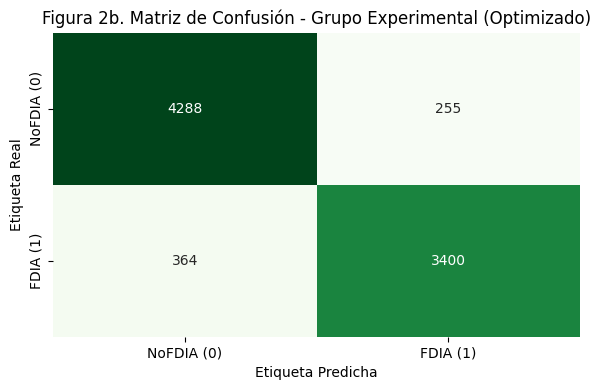

In [44]:
# ==========================================
# CELDA 19: Matriz de Confusión Optimizada
# ==========================================
cm_opt = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['NoFDIA (0)', 'FDIA (1)'],
            yticklabels=['NoFDIA (0)', 'FDIA (1)'])
plt.title('Figura 2b. Matriz de Confusión - Grupo Experimental (Optimizado)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()